In [8]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import time
import librosa
import librosa.display
import musdb
import demucs.api
import museval
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path

sys.path.append("..")

FFMPEG_BIN = str(Path("../tools/ffmpeg/bin").resolve())
os.environ["PATH"] += os.pathsep + FFMPEG_BIN

In [7]:
def separate_demo(input_file):
    input_path = Path(input_file)
    print(f"Разделение трека {input_path.name}")
    
    y, sr = librosa.load(input_path, sr=None, mono=False)
    y_trimmed, _ = librosa.effects.trim(y, top_db=50)
    mix_tensor = torch.tensor(y_trimmed, dtype=torch.float32)

    separator = demucs.api.Separator(model="htdemucs")
    _, separated = separator.separate_tensor(mix_tensor, sr=sr)

    for stem, tensor in separated.items():
        print(f"Stem '{stem}' shape: {tensor.shape}")
    print("Разделение завершено.")

demo_track_path = Path("../samples/The Police - Every Breath You Take.mp3").resolve()
separate_demo(demo_track_path)

Разделение трека The Police - Every Breath You Take.mp3
Stem 'drums' shape: torch.Size([2, 11005440])
Stem 'bass' shape: torch.Size([2, 11005440])
Stem 'other' shape: torch.Size([2, 11005440])
Stem 'vocals' shape: torch.Size([2, 11005440])
Разделение завершено.


In [10]:
MUSDB_ROOT = "../musdb18"
N_TRACKS = 5 
STEMS = ["vocals", "drums", "bass", "other"]

mus = musdb.DB(root=MUSDB_ROOT, subsets="test")
separator = demucs.api.Separator(model="htdemucs")
all_scores = {stem: {"SDR": [], "SIR": [], "SAR": []} for stem in STEMS}

total_processing_time = 0

for track in mus.tracks[:N_TRACKS]:
    print(f"Обработка {track.name}")

    start_time = time.time()

    mix_tensor = torch.tensor(track.audio.T, dtype=torch.float32)
    with torch.no_grad():
        _, separated = separator.separate_tensor(mix_tensor, sr=track.rate)
    
    elapsed_time = time.time() - start_time
    total_processing_time += elapsed_time
    print(f"Время инференса: {elapsed_time:.2f} сек.")

    estimates = {s: separated[s].numpy().T for s in STEMS}
    scores = museval.eval_mus_track(track, estimates)
    
    for stem in STEMS:
        all_scores[stem]["SDR"].append(np.nanmedian(scores.df.query(f"target == '{stem}' and metric == 'SDR'")["score"]))
        all_scores[stem]["SIR"].append(np.nanmedian(scores.df.query(f"target == '{stem}' and metric == 'SIR'")["score"]))
        all_scores[stem]["SAR"].append(np.nanmedian(scores.df.query(f"target == '{stem}' and metric == 'SAR'")["score"]))

avg_time = total_processing_time / N_TRACKS
print(f"\nСреднее время инференса на один трек: {avg_time:.2f} сек.")

Обработка AM Contra - Heart Peripheral
Время инференса: 273.02 сек.
Обработка Al James - Schoolboy Facination
Время инференса: 267.87 сек.
Обработка Angels In Amplifiers - I'm Alright
Время инференса: 233.05 сек.
Обработка Arise - Run Run Run
Время инференса: 285.79 сек.
Обработка BKS - Bulldozer
Время инференса: 439.42 сек.

Среднее время инференса на один трек: 299.83 сек.


In [27]:
track_names = [t.name for t in mus.tracks[:N_TRACKS]]
rows = []

for i, name in enumerate(track_names):
    for stem in STEMS:
        rows.append({
            "Track": name,
            "Stem": stem,
            "SDR": all_scores[stem]["SDR"][i],
            "SIR": all_scores[stem]["SIR"][i],
            "SAR": all_scores[stem]["SAR"][i]
        })

df_detailed = pd.DataFrame(rows)
df_final = df_detailed.set_index(['Track', 'Stem'])

styled_table = df_final.style.format("{:+.2f}") \
    .set_table_styles([
        {'selector': 'tbody tr:nth-child(4n+1)', 
         'props': [('border-top', '2px solid #444')]}
    ]) \
    .set_properties(**{'text-align': 'left', 'padding': '10px'})

display(styled_table)

In [11]:
def show_summary_table(all_scores):
    summary_data = []
    for stem in STEMS:
        summary_data.append({
            "Stem": stem,
            "SDR (dB)": np.mean(all_scores[stem]["SDR"]),
            "SIR (dB)": np.mean(all_scores[stem]["SIR"]),
            "SAR (dB)": np.mean(all_scores[stem]["SAR"])
        })
    
    df = pd.DataFrame(summary_data)
    
    df = df.set_index("Stem")
    
    return df.round(2)

df_results = show_summary_table(all_scores)
display(df_results)

,SDR (dB),SIR (dB),SAR (dB)
Stem,,,
vocals,8.74,18.30,8.54
drums,6.35,10.74,8.32
bass,7.70,12.39,9.58
other,4.23,9.29,4.29


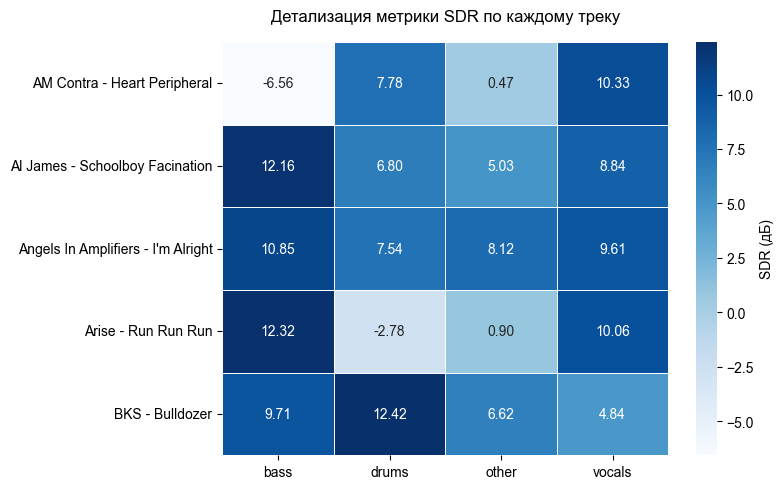

In [38]:
def plot_heatmap(df_detailed, metric="SDR"):
    pivot_df = df_detailed.pivot(index="Track", columns="Stem", values=metric)
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="Blues", 
                cbar_kws={'label': f'{metric} (дБ)'}, linewidths=.5)
    
    plt.title(f"Детализация метрики {metric} по каждому треку", pad=15)
    plt.ylabel("")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

plot_heatmap(df_detailed, metric="SDR")

Вокал является самым стабильным стемом, почти во всех треках показывает результат около 9–10 дБ. Однако в треке BKS - Bulldozer мы видим резкое падение до 4.84 дБ, возможно, это связано с тем, что интенсивность барабанов может перебивать вокальную дорожку.

Что касается bass, провал в треке AM Contra - Heart Peripheral до -6.56 дБ свидетельствует о том, что модель не смогла отделить бас от других источников, приняв искажения за полезный сигнал.

Низкие результаты drums в треке Arise - Run Run Run (-2.78 дБ) при отличном качестве баса (12.32 дБ) говорят о том, что ударные были ошибочно классифицированы как бас.

Категория Other является самой слабой. Средний показатель едва достигает 4.2 дБ, а в двух треках падает практически до нуля (0.47 и 0.90). Стэмы Other лишены специфических звуковых признаков, из-за чего модель не может выделить их так же эффективно, как вокал или ударные.